# El mapa del vacío

Cuánto del transporte de cargas argentino vuelve sin carga, medido con los
datos oficiales. La Secretaría de Transporte publica, para 2012, 2014, 2016 y
2018, una matriz origen-destino entre 123 zonas para 113 productos, en
toneladas y en camiones, y la asignación de esos camiones a la red vial, tramo
por tramo y por sentido. Con eso se puede responder tres preguntas que ningún
sistema de matching de cargas puede cambiar: cuánto del país es corredor de un
solo sentido, dónde está ese vacío y qué cargas podrían emparejarse.

La pregunta nació en los comentarios de la ruta de la arena: todos los camiones
vuelven vacíos, ¿qué podría volver cargado desde Neuquén? Acá la arena es el
caso extremo, y la respuesta sale de mirar los otros 112 productos.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, geopandas as gpd
from IPython.display import IFrame, Image, display

from vlab import DATA_PROC, DOCS, FIGURES, ANIOS
from vlab.od import zones, all_products, find_file, read_workbook, asymmetry, structural_empty, zone_flows
from vlab.network import load_network, link_imbalance, summary, by_route, all_groups
from vlab.maps import empty_map, empty_figure
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 60)
z = zones(); codes = list(z.codigo); nombre = dict(zip(z.codigo, z.centroide))
print(len(z), "zonas de tráfico; ejemplo:"); z.head(3)

123 zonas de tráfico; ejemplo:


,id,codigo,provincia,centroide,lon,lat
0,1,ACA,SALTA,CAFAYATE,-65.976032,-26.072917
1,2,ACP,SALTA,SALTA,-65.410319,-24.789295
2,3,AME,SALTA,METAN,-64.971005,-25.496974


## 1. El vacío estructural, par por par

Para cada producto, cada par de zonas tiene una ida y una vuelta. Lo que va en
un sentido y no tiene contraparte en el otro es vacío estructural: un camión
que lleva soja a Rosario no tiene soja que traer de vuelta, y eso no lo arregla
ninguna aplicación. Lo intrazonal queda afuera, porque no recorre corredores.

In [2]:
M = all_products(2018, codes)
resumen = []
for (grupo, producto), m in M.items():
    e = structural_empty(m)
    resumen.append({"grupo": grupo, "producto": producto, **e})
R = pd.DataFrame(resumen)
por_grupo = R.groupby("grupo")[["total", "emparejado", "vacio_estructural"]].sum()
por_grupo["pct_sin_vuelta"] = 100 * por_grupo.vacio_estructural / por_grupo.total
print(f"{len(M)} productos; {R.total.sum() / 1e6:,.1f} Mt entre zonas en 2018, {100 * R.vacio_estructural.sum() / R.total.sum():.0f} % sin carga de vuelta en el mismo par")
por_grupo.sort_values("total", ascending=False).round(0)

111 productos; 244.6 Mt entre zonas en 2018, 95 % sin carga de vuelta en el mismo par


,total,emparejado,vacio_estructural,pct_sin_vuelta
grupo,,,,
granos,71038949.0,4429125.0,66609824.0,94.0
semiterminados,40416230.0,585572.0,39830658.0,99.0
combustibles,32588438.0,2021434.0,30567004.0,94.0
regionales,22440473.0,43092.0,22397381.0,100.0
industrializados,21699794.0,2851540.0,18848254.0,87.0
"mineria extraccion de arenas, canto. rod. y trit. petreos",16944119.0,0.0,16944119.0,100.0
mineria extraccion de piedra caliza y yeso,11866995.0,0.0,11866995.0,100.0
ganado en pie,8277234.0,2755460.0,5521775.0,67.0
mineria explotacion de minas y canteras ncp,5136453.0,0.0,5136453.0,100.0


La lectura por producto es más dura que por grupo, porque dentro de un grupo
una carga puede compensar a otra que no viaja en el mismo camión.

In [3]:
R[R.total > 200000].sort_values("pct_sin_vuelta", ascending=False)[["grupo", "producto", "total", "vacio_estructural", "pct_sin_vuelta"]].head(15).round(0)

,grupo,producto,total,vacio_estructural,pct_sin_vuelta
1,carnes,porcinos,204140.0,204140.0,100.0
3,carnes,avicola,1526397.0,1526397.0,100.0
5,combustibles,biodiesel,1062232.0,1062232.0,100.0
6,combustibles,bioetanol,872833.0,872833.0,100.0
10,combustibles,lubricantes,213386.0,213386.0,100.0
8,combustibles,nafta,4142818.0,4142818.0,100.0
46,mineria explotacion de minas y canteras ncp,tosca,4869513.0,4869513.0,100.0
93,regionales,naranja,823298.0,823298.0,100.0
91,regionales,mandarina,359536.0,359536.0,100.0
90,regionales,limon,1012312.0,1012312.0,100.0


## 2. El vacío tramo por tramo

La red simplificada tiene 1.731 tramos con los camiones por año en cada
sentido. La diferencia entre los dos sentidos son camiones que cruzan el tramo
cargados y vuelven sin nada: el vacío de ese tramo. Multiplicado por el largo,
da camiones-kilómetro vacíos por año.

In [4]:
net = link_imbalance(load_network())
s = summary(net)
print(f"{s['tramos']} tramos, {s['km_red']:,.0f} km de red; {s['camiones_km_total'] / 1e9:,.2f} mil millones de camiones-km por año, {s['pct_vacio']:.0f} % en el sentido sin carga de vuelta")
by_route(net, 12).round(0)

1731 tramos, 58,058 km de red; 8.11 mil millones de camiones-km por año, 43 % en el sentido sin carga de vuelta


,etiqueta,km,camiones_km,vacio_km,pct_vacio
0,RN 9,1926.0,1.322861e+09,518889439.0,39.0
1,RN 3,3108.0,7.863294e+08,435047326.0,55.0
2,RN 34,1329.0,9.038791e+08,326640412.0,36.0
3,RN 14,1048.0,5.212064e+08,285401662.0,55.0
4,RN 33,791.0,2.970882e+08,223901345.0,75.0
5,RN 12,1579.0,2.841035e+08,141997869.0,50.0
6,RN 40,4979.0,1.876269e+08,123233481.0,66.0
7,RN 7,1209.0,3.796398e+08,105379419.0,28.0
8,RN 35,711.0,2.038759e+08,94246275.0,46.0
9,RN 22,686.0,1.224491e+08,63110828.0,52.0


In [5]:
por_grupo_red = all_groups()
por_grupo_red.round(0)

,grupo,camiones_km_total,camiones_km_vacios,pct_vacio,tramos,km_red
0,mineria,2.033514e+09,1.546343e+09,76.0,1731,58058.0
1,granos,1.412775e+09,1.215520e+09,86.0,1731,58058.0
2,regionales,1.423424e+09,1.135976e+09,80.0,1731,58058.0
3,combustibles,1.687803e+09,1.080287e+09,64.0,1731,58058.0
4,semiterminados,6.034131e+08,4.112860e+08,68.0,1731,58058.0
5,industrializados,6.041683e+08,3.412551e+08,56.0,1731,58058.0
6,ganado en pie,2.480152e+08,1.407356e+08,57.0,1731,58058.0
7,carnes,9.680614e+07,7.825900e+07,81.0,1731,58058.0


Dos cosas que conviene leer con cuidado. El 43 % nacional mezcla productos:
un tramo puede estar equilibrado en total y muy desbalanceado producto por
producto, como muestra la tabla por grupo, donde granos, carnes y regionales
pasan del 80 %. Y el desbalance en camiones no siempre es un camión vacío: un
tolva de granos no puede traer vehículos de vuelta aunque el tramo los tenga.

## 3. La arena de fractura, el caso extremo

El registro de fractura de la Secretaría de Energía dice que en 2018 se
bombearon 934.000 toneladas de arena nacional en Vaca Muerta. La matriz de
transporte del mismo año tiene una hoja para arena silícea. ¿Ve la matriz esa
arena?

In [6]:
neu = ["QCP", "QZA", "RGR", "RRC"]   # Neuquén, Zapala, General Roca, Río Colorado: el destino y el Alto Valle
for anio in (2016, 2018):
    m = read_workbook(anio, find_file(anio, "arenas" if anio == 2018 else "mineria"), codes)
    k = [h for h in m if "silic" in h][0]; a = m[k]
    print(f"{anio}: arena silícea en la matriz {a.values.sum() / 1e6:,.2f} Mt; con destino Neuquén y Alto Valle {a[neu].sum().sum():,.0f} t; sin vuelta {structural_empty(a)['pct_sin_vuelta']:.0f} %")
top = asymmetry(a).head(8); top["origen"] = top.origen.map(nombre); top["destino"] = top.destino.map(nombre); top.round(0)

2016: arena silícea en la matriz 0.99 Mt; con destino Neuquén y Alto Valle 23,475 t; sin vuelta 100 %


2018: arena silícea en la matriz 1.70 Mt; con destino Neuquén y Alto Valle 40,072 t; sin vuelta 100 %


,origen,destino,ida,vuelta,sin_vuelta
0,GUALEGUAYCHU,CABA,590477.0,0.0,1.0
1,COMODORO RIVADAVIA,CORDOBA,84631.0,0.0,1.0
2,COMODORO RIVADAVIA,MENDOZA,62760.0,0.0,1.0
3,NOGOYA,ROSARIO,34049.0,0.0,1.0
4,PARANÁ,TUCUMAN,31001.0,0.0,1.0
5,BAHIA BLANCA,MAR DEL PLATA,29738.0,0.0,1.0
6,COMODORO RIVADAVIA,SAN JUAN,26910.0,0.0,1.0
7,PARANÁ,SANTA FE,26888.0,0.0,1.0


No la ve. La matriz oficial de 2018 registra unas 40.000 toneladas de arena
silícea hacia Neuquén y el Alto Valle, contra 934.000 del registro de
fractura: menos del 5 %. El flujo de carga nuevo más grande de la década no
está en la estadística de transporte que se usa para planificar rutas. Es un
límite del dato, y también un resultado.

## 4. Qué podría volver cargado desde Neuquén

La pregunta del post. Con las 111 matrices de 2018 se puede listar todo lo que
sale de Neuquén y el Alto Valle hacia el resto del país, y hacia dónde va.

In [7]:
sale = zone_flows(M, neu, "sale"); entra = zone_flows(M, neu, "entra")
print(f"entra: {entra.t.sum() / 1e6:,.1f} Mt por año; sale: {sale.t.sum() / 1e6:,.1f} Mt")
print("lo que sale, por producto:"); display(sale.groupby("producto").t.sum().sort_values(ascending=False).head(10).round(0).to_frame())
print("y hacia dónde:"); sale.assign(contraparte=sale.contraparte.map(nombre)).groupby("contraparte").t.sum().sort_values(ascending=False).head(10).round(0).to_frame()

entra: 2.6 Mt por año; sale: 5.8 Mt
lo que sale, por producto:


,t
producto,
diesel,1232595.0
gas,1162484.0
peras y manzana,971025.0
otros combust,737352.0
nafta,727354.0
canto rodado,308796.0
caliza,154022.0
arena const.,136453.0
bentonita,90779.0


y hacia dónde:


,t
contraparte,
COMODORO RIVADAVIA,791278.0
TRELEW,667720.0
RIO GALLEGOS,527204.0
BARILOCHE,493697.0
CALETA OLIVIA,367498.0
RIO GRANDE,353896.0
S.A. OESTE,334588.0
ESQUEL,267873.0
CABA,236143.0


La respuesta tiene dos partes. Lo que más sale de Neuquén son combustibles, y
van al sur: Comodoro Rivadavia, Trelew, Río Gallegos. No sirven para el camión
de arena, que vuelve al norte, y además viajan en cisterna. Lo que sí va al
norte son las peras y manzanas del Alto Valle, casi un millón de toneladas por
año, en la misma dirección que la batea vacía. El problema es el equipo: la
fruta va en pallets y con frío, la arena en tolva. El vacío de la arena es
estructural dos veces: por dirección y por equipo.

## 5. El mapa

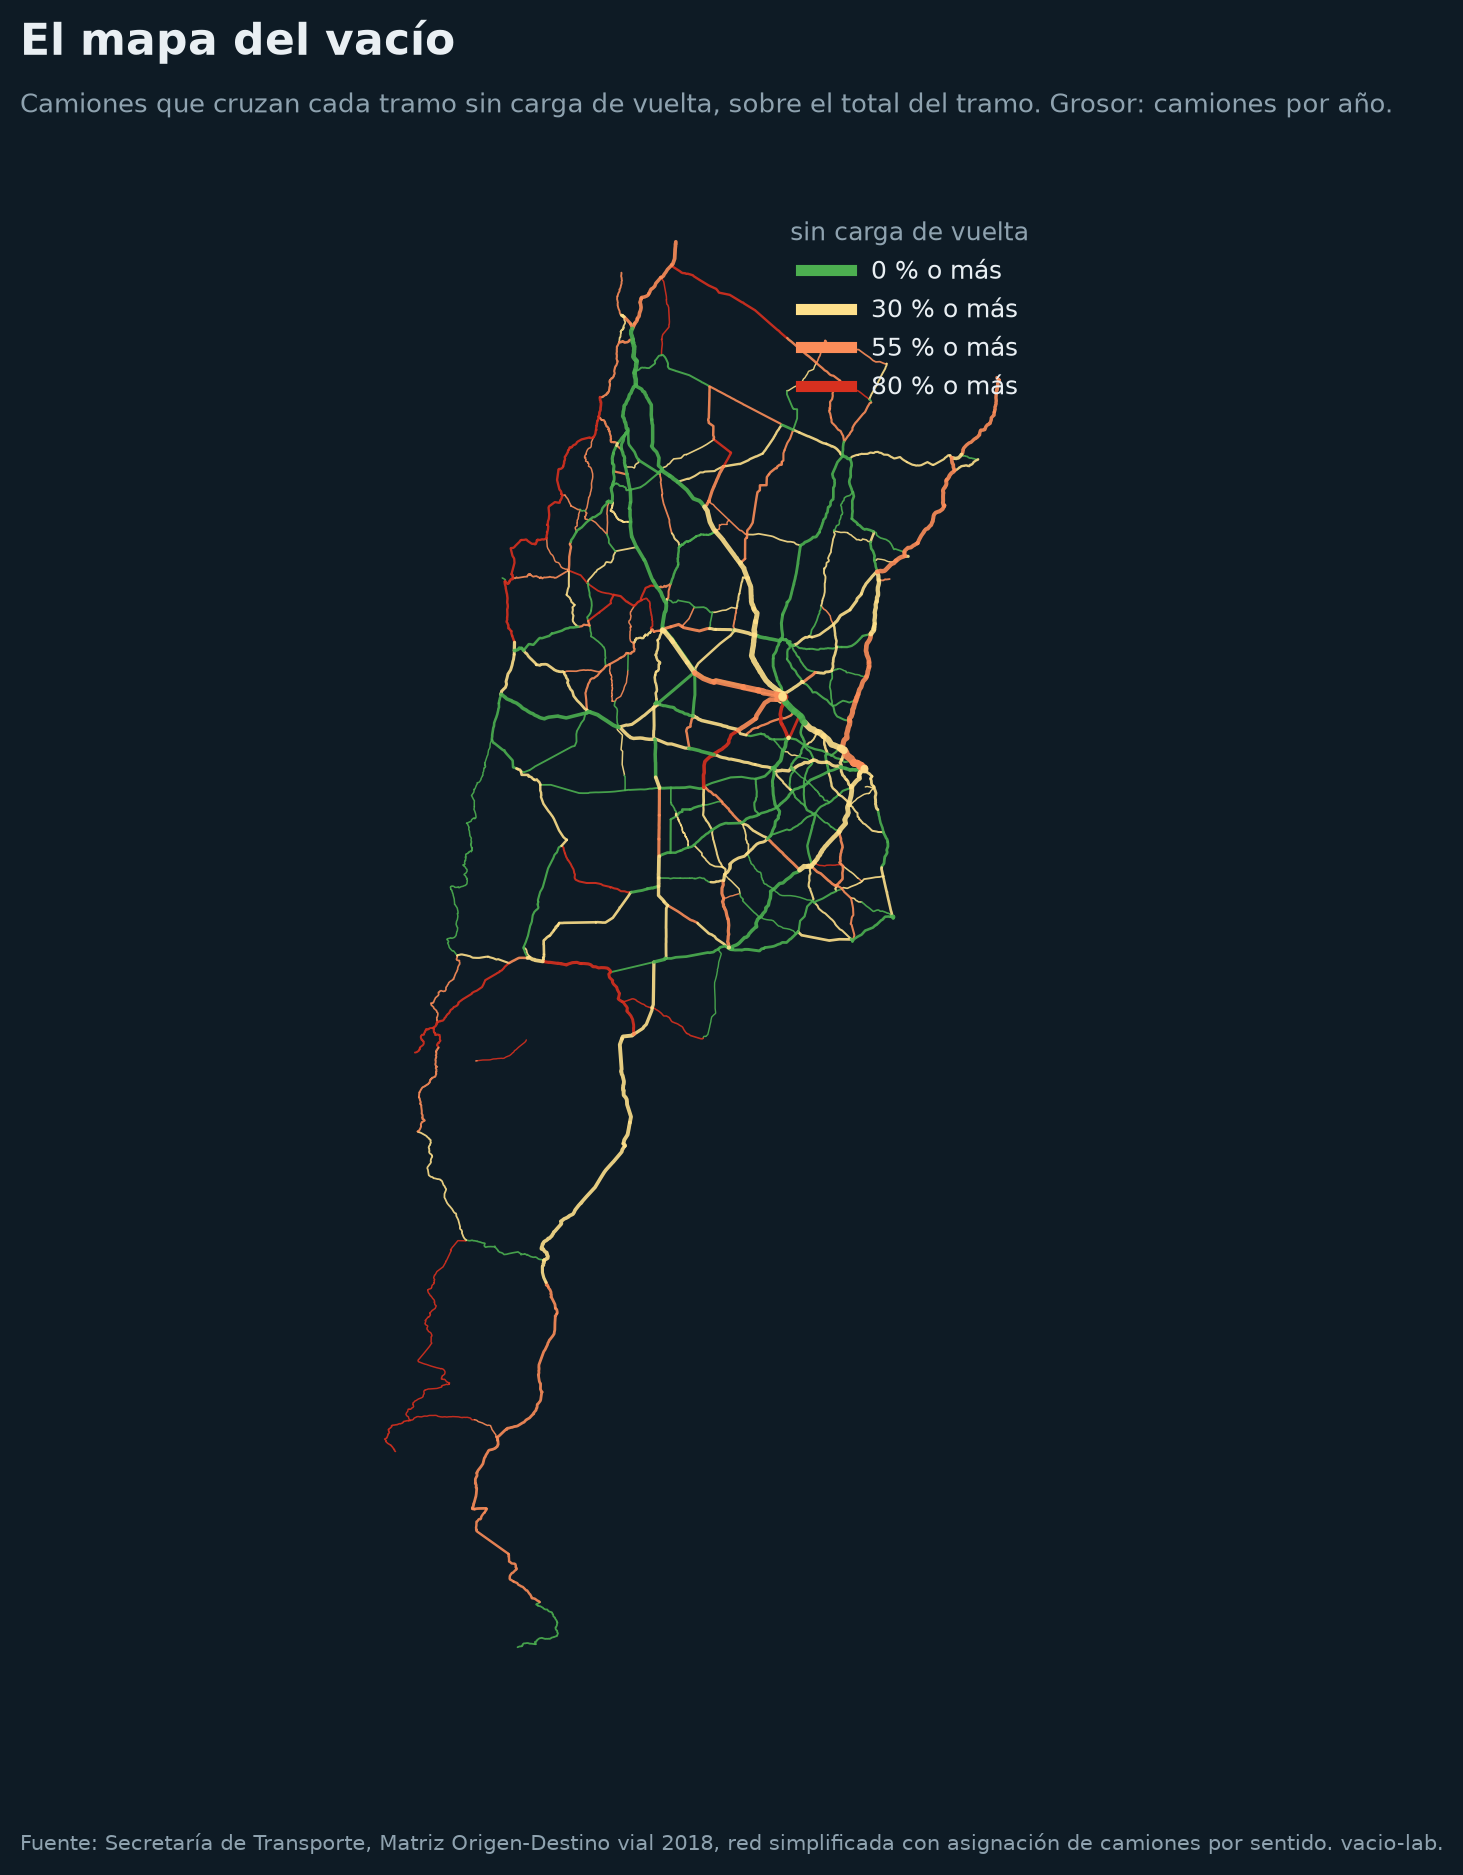

In [8]:
empty_map(net, DOCS / "mapa_vacio.html", zonas=z)
fig = empty_figure(net, FIGURES / "mapa_vacio.png")
net.drop(columns="geometry").to_csv(DATA_PROC / "tramos_vacio_2018.csv", index=False); R.to_csv(DATA_PROC / "vacio_por_producto_2018.csv", index=False)
display(Image(filename=str(fig)))
IFrame("../docs/mapa_vacio.html", width="100%", height=620)

## Límites

- Los datos son de 2018, la última edición publicada. Vaca Muerta triplicó su
  arena desde entonces y la matriz de ese año ya no la veía.
- La matriz es una estimación oficial a partir de registros administrativos
  (SENASA, cartas de porte, permisos) y modelos, asignada a una red vial
  simplificada de 1.731 tramos. No es un conteo de camiones.
- El vacío por tramo se calcula sobre el total de todos los productos. Por
  producto es mayor, y por equipo, más todavía: una tolva no lleva pallets.
- Las zonas son 123 grupos de departamentos con un centroide geocodificado en
  OpenStreetMap; lo intrazonal, un 15 a 30 % según el producto, queda afuera.
- Un desbalance en toneladas no es un camión vacío exacto: la conversión a
  camiones usa densidades por producto que hace la propia Secretaría.